In [14]:
import pandas as pd
import geopandas as gpd
from pathlib import Path
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import random

Define input data directory

In [3]:
input_dir = Path("~/work/Gitlab/nwm-region-mgr/inputs").expanduser()

Function to sample a subset of locations from a given set of locations (for calibration basins)

In [4]:
def sample_locations(locations, n_samples):
    """Select a uniform sample of locations using KMeans clustering.
    
    Args:
        locations: DataFrame with 'latitude' and 'longitude' columns.
        n_samples: Number of locations to sample.
    
    Returns:
        DataFrame with sampled locations.

    """
    if len(locations) <= n_samples:
        return locations  

    # Convert to numpy array for clustering
    coords = locations[['latitude', 'longitude']].to_numpy()

    # Apply KMeans clustering
    kmeans = KMeans(n_clusters=n_samples, random_state=42, n_init=10)
    kmeans.fit(coords)
    
    # Find the closest point to each cluster center
    sampled_indices = []
    for center in kmeans.cluster_centers_:
        closest_idx = np.argmin(np.linalg.norm(coords - center, axis=1))
        sampled_indices.append(closest_idx)

    return locations.iloc[sampled_indices]

Function to plot all calibration basins on a map with sampled basins highlighted

In [5]:
#Plots all calibration basins on a map with sampled basins highlighted
def plot_map_static(locations, sampled_locations, domain, crs='EPSG:4326'):
    """Plot all locations and sampled locations on a basemap using GeoPandas + Contextily.
    
    :param locations: DataFrame with 'latitude' and 'longitude' columns
    :param sampled_locations: same structure
    :param domain: name of the domain for the plot title
    :param crs: coordinate reference system (default is WGS84)
    """
    # Convert DataFrames to GeoDataFrames
    gdf_all = gpd.GeoDataFrame(locations.copy(),
                               geometry=gpd.points_from_xy(locations.longitude, locations.latitude),
                               crs=crs)

    gdf_sampled = gpd.GeoDataFrame(sampled_locations.copy(),
                                   geometry=gpd.points_from_xy(sampled_locations.longitude, sampled_locations.latitude),
                                   crs=crs)

    # Project to Web Mercator for contextily
    gdf_all_web = gdf_all.to_crs(epsg=3857)
    gdf_sampled_web = gdf_sampled.to_crs(epsg=3857)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 8))
    gdf_all_web.plot(ax=ax, color='orange', markersize=10, alpha=0.8, 
                     label=f'All calibration basins ({len(gdf_all)})')
    gdf_sampled_web.plot(ax=ax, facecolor='none', edgecolor='red', markersize=30, 
                         label=f'Sampled calibration basins ({len(gdf_sampled)})')


    # Add basemap
    # Uncomment one of the following lines to use a different basemap, but Stamen does not work with the latest contextily
    #ctx.add_basemap(ax, source=ctx.providers.Stamen.Terrain)
    #ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
    ctx.add_basemap(ax, source=ctx.providers.Esri.WorldImagery)
    #ctx.add_basemap(ax, source=ctx.providers.Stamen.TonerLite)
    #ctx.add_basemap(ax, source=ctx.providers.Stamen.Watercolor)
    #ctx.add_basemap(ax, source=ctx.providers.OpenTopoMap)

    ax.set_axis_off()
    ax.set_title(f"Spatial Distribution of Calibration Basins: {domain}", fontsize=14)
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

Define formulations

In [ ]:
# selection of formulations
formulations = [
    "noah-owp-modular cfe-s t-route",
    "noah-owp-modular cfe-x t-route",
    "noah-owp-modular lasam t-route",
    "noah-owp-modular sac-sma t-route",
    "noah-owp-modular ueb cfe-s t-route",
    "noah-owp-modular snow-17 cfe-s t-route",
    "noah-owp-modular snow-17 cfe-x t-route",
    "noah-owp-modular snow-17 sac-sma t-route",
    "noah-owp-modular snow-17 lasam t-route",
    "noah-owp-modular ueb lasam t-route",
    "noah-owp-modular ueb topmodel t-route",
    "noah-owp-modular snow-17 topmodel t-route",
    "noah-owp-modular topmodel t-route",
    "noah-owp-modular ueb cfe-x t-route",
]

# number of formulations calibrated for each VPU
n_form = 3

Define domain (availabe domains: conus, ak, hi, prvi)

In [7]:
domain1 = "ak"

Read calib/valid stats from NWMv3 calibration

In [8]:
stats = ['bias','rmse', 'cor', 'nse', 'nselog', 'nseWt', 'kge', 'msof',
       'hyperResMultiObj', 'nnsesq', 'eventmultiobj', 'lbem', 'lbemprime',
       'corr1', 'pod', 'far', 'csi', 'nnse', 'peak_bias', 'peak_tm_err_hr',
       'event_volume_bias']
stats_dict = {}
for eval_period in ['calib','valid','full']:    
       statsAll = pd.read_csv(Path(input_dir, 'stats_calib_valid_nwmv3.csv'))
       statsAll['simulation'] = 'calibrated'
       statsAll = statsAll[(statsAll['simulation']=='calibrated') & (statsAll['evalPeriod']==eval_period) & (statsAll['jobID']<100)]
       statsAll = statsAll[['evalPeriod'] + stats]
       statsAll['gage_idx'] = range(0, len(statsAll))
       statsAll.insert(0,'gage_idx', statsAll.pop('gage_idx'))

       stats_dict[eval_period] = statsAll
#display(stats_dict['calib'])

Read catchment-gage crosswalk

In [9]:
cwt_file = Path(input_dir, 'cwt_divide_gage', 'calib_gage_divide_' + domain1 + '.parquet')
if not cwt_file.exists():
    print(f"Crosswalk file {cwt_file} does not exist. Please run the script to create it.")
else:
    df_cats = pd.read_parquet(cwt_file)

Create sample locations and plot them on map (assuming these locations are calibrated for multiple formulations)

Sample 26 locations from a total of 26 in the ak domain


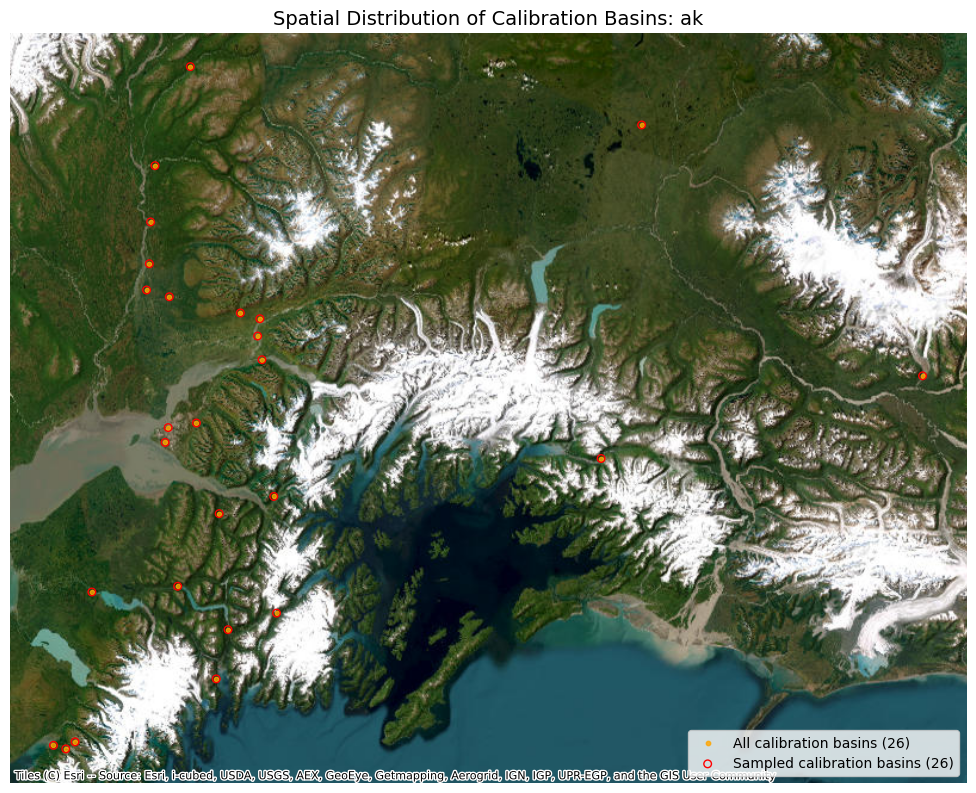

In [12]:
n_sample = 1000
gages = pd.read_csv(Path(input_dir, "gages_nwm4_calib_all.csv"))
df_gages = df_cats.merge(gages[['gage_id','latitude','longitude']], how='left')[['gage_id','latitude','longitude','vpuid']]
df_gages = df_gages.drop_duplicates()
df_gages = df_gages[~df_gages['latitude'].isna() | ~df_gages['longitude'].isna()]
if n_sample > len(df_gages):
    n_sample = len(df_gages)
print(f'Sample {n_sample} locations from a total of {len(df_gages)} in the {domain1} domain')
sampled_gages = sample_locations(df_gages, n_sample).reset_index().drop(columns=['index'])
#display(sampled_gages)

# plot the map with sampled locations
plot_map_static(df_gages, sampled_gages, domain1)

Create pseudo cal/val stats from existing NMWv3 cal/val stats for the sampled basins for a number of formulations. Here, sample locations in each VPU are assumed to be calbirated for a different set of formuations.

In [ ]:
# loop through vpus to generate pesudo stats
df_stats = pd.DataFrame()
for vpu in sampled_gages['vpuid'].unique():
    # randomly select a subset of formulations for each VPU
    forms = [formulations[x] for x in random.sample(range(len(formulations)), n_form)]
    gage_idxs = sampled_gages[sampled_gages['vpuid'] == vpu].index
    
    # loop through selected formulations to assign stats for each sample location
    for form1 in forms:

        # randomly select gage indices from the stats_dict['calib'] for each formulation
        stats_idxs = [random.randint(stats_dict['calib']['gage_idx'].min(), stats_dict['calib']['gage_idx'].max())
                      for _ in range(n_sample)]
        for eval_period in stats_dict.keys():

            df1 = stats_dict[eval_period].set_index('gage_idx').reindex(stats_idxs).reset_index().loc[gage_idxs]
            df2 = sampled_gages.loc[gage_idxs]
            df1 = pd.concat([df2, df1], axis=1)
            df1 = df1.drop(columns=['gage_idx'])

            df1['formulation'] = form1
            df1.insert(0,'formulation', df1.pop('formulation'))
            df1.insert(0,'gage_id', df1.pop('gage_id'))
            
            df_stats = pd.concat([df_stats, df1], axis=0, ignore_index=True)

df_stats = df_stats.sort_values(by=['gage_id', 'formulation', 'evalPeriod'])
print(f"There are {len(df_stats)/3} calibration/validation runs for {len(df_stats['gage_id'].unique())} "
      f"sampled basins in the {domain1} domain")
print(f"Missed gages: {[g for g in sampled_gages['gage_id'].unique() if g not in df_stats['gage_id'].unique()]}")

df_stats = df_stats.drop(columns=['latitude', 'longitude', 'vpuid'])

# write out all stats for all formulations to a single csv file, and then again to a single parquet file
outfile = Path(input_dir, 'calval_stats/stat_calval_all_' + domain1 + '.csv')
if not outfile.parent.exists():
    outfile.parent.mkdir(parents=True, exist_ok=True)
df_stats.to_csv(outfile, index=False)
print(f"All stats written to {outfile}")

outfile_parquet = Path(input_dir, 'calval_stats/stat_calval_all_' + domain1 + '.parquet')
if not outfile_parquet.parent.exists():
    outfile_parquet.parent.mkdir(parents=True, exist_ok=True)
df_stats.to_parquet(outfile_parquet, index=False)
print(f"All stats written to {outfile_parquet}")

There are 78.0 calibration/validation runs for 26 sampled basins in the ak domain
Missed gages: []
All stats written to /home/yuqiong.liu/work/Gitlab/nwm-region-mgr/inputs/calval_stats/stat_calval_all_ak.csv
All stats written to /home/yuqiong.liu/work/Gitlab/nwm-region-mgr/inputs/calval_stats/stat_calval_all_ak.parquet
